In [22]:
import pandas as pd
data = pd.read_csv("train_FD001.txt", sep=" ", header=None)

# Remove empty columns
data = data.dropna(axis=1)

print(data.head())

   0   1       2       3      4       5       6        7        8      9   \
0   1   1 -0.0007 -0.0004  100.0  518.67  641.82  1589.70  1400.60  14.62   
1   1   2  0.0019 -0.0003  100.0  518.67  642.15  1591.82  1403.14  14.62   
2   1   3 -0.0043  0.0003  100.0  518.67  642.35  1587.99  1404.20  14.62   
3   1   4  0.0007  0.0000  100.0  518.67  642.35  1582.79  1401.87  14.62   
4   1   5 -0.0019 -0.0002  100.0  518.67  642.37  1582.85  1406.22  14.62   

   ...      16       17       18      19    20   21    22     23     24  \
0  ...  521.66  2388.02  8138.62  8.4195  0.03  392  2388  100.0  39.06   
1  ...  522.28  2388.07  8131.49  8.4318  0.03  392  2388  100.0  39.00   
2  ...  522.42  2388.03  8133.23  8.4178  0.03  390  2388  100.0  38.95   
3  ...  522.86  2388.08  8133.83  8.3682  0.03  392  2388  100.0  38.88   
4  ...  522.19  2388.04  8133.80  8.4294  0.03  393  2388  100.0  38.90   

        25  
0  23.4190  
1  23.4236  
2  23.3442  
3  23.3739  
4  23.4044  

[5 rows

In [23]:
data.columns = [
'engine_id','cycle','setting1','setting2','setting3',
'sensor1','sensor2','sensor3','sensor4','sensor5',
'sensor6','sensor7','sensor8','sensor9','sensor10',
'sensor11','sensor12','sensor13','sensor14',
'sensor15','sensor16','sensor17','sensor18',
'sensor19','sensor20','sensor21'
]
print(data.shape)
print(data.describe())

(20631, 26)
          engine_id         cycle      setting1      setting2  setting3  \
count  20631.000000  20631.000000  20631.000000  20631.000000   20631.0   
mean      51.506568    108.807862     -0.000009      0.000002     100.0   
std       29.227633     68.880990      0.002187      0.000293       0.0   
min        1.000000      1.000000     -0.008700     -0.000600     100.0   
25%       26.000000     52.000000     -0.001500     -0.000200     100.0   
50%       52.000000    104.000000      0.000000      0.000000     100.0   
75%       77.000000    156.000000      0.001500      0.000300     100.0   
max      100.000000    362.000000      0.008700      0.000600     100.0   

            sensor1       sensor2       sensor3       sensor4       sensor5  \
count  2.063100e+04  20631.000000  20631.000000  20631.000000  2.063100e+04   
mean   5.186700e+02    642.680934   1590.523119   1408.933782  1.462000e+01   
std    6.537152e-11      0.500053      6.131150      9.000605  3.394700e-12

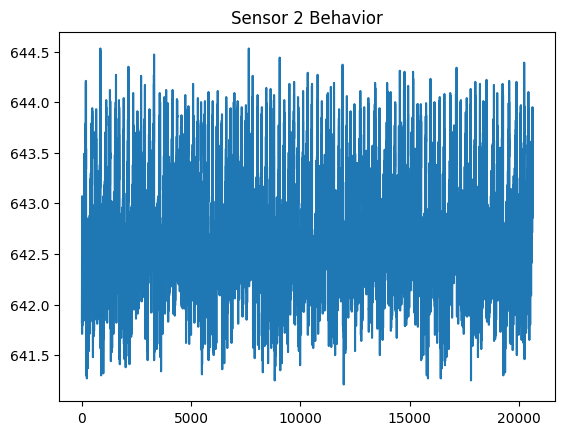

In [24]:
import matplotlib.pyplot as plt

plt.plot(data['sensor2'])
plt.title("Sensor 2 Behavior")
plt.show()

In [25]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(data[['sensor2','sensor3','sensor4']])

In [26]:
features = ['sensor2','sensor3','sensor4','sensor7','sensor11']
X = data[features]

In [27]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [28]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.05, random_state=42)
model.fit(X_scaled)

IsolationForest(contamination=0.05, random_state=42)

In [29]:
data['anomaly'] = model.predict(X_scaled)

In [30]:
print(data['anomaly'].value_counts())

anomaly
 1    19599
-1     1032
Name: count, dtype: int64


In [31]:
anomalies = data[data['anomaly'] == -1]

print(anomalies.head())

     engine_id  cycle  setting1  setting2  setting3  sensor1  sensor2  \
181          1    182   -0.0010    0.0003     100.0   518.67   644.21   
183          1    184    0.0004    0.0003     100.0   518.67   644.07   
184          1    185    0.0008    0.0001     100.0   518.67   643.80   
186          1    187   -0.0047   -0.0000     100.0   518.67   643.32   
188          1    189   -0.0006    0.0002     100.0   518.67   644.18   

     sensor3  sensor4  sensor5  ...  sensor13  sensor14  sensor15  sensor16  \
181  1602.08  1426.62    14.62  ...   2388.25   8119.67    8.5158      0.03   
183  1605.44  1432.52    14.62  ...   2388.28   8115.61    8.5133      0.03   
184  1603.46  1424.40    14.62  ...   2388.27   8113.69    8.4984      0.03   
186  1592.10  1427.27    14.62  ...   2388.28   8115.67    8.5218      0.03   
188  1596.17  1428.01    14.62  ...   2388.33   8117.51    8.5183      0.03   

     sensor17  sensor18  sensor19  sensor20  sensor21  anomaly  
181       397      23

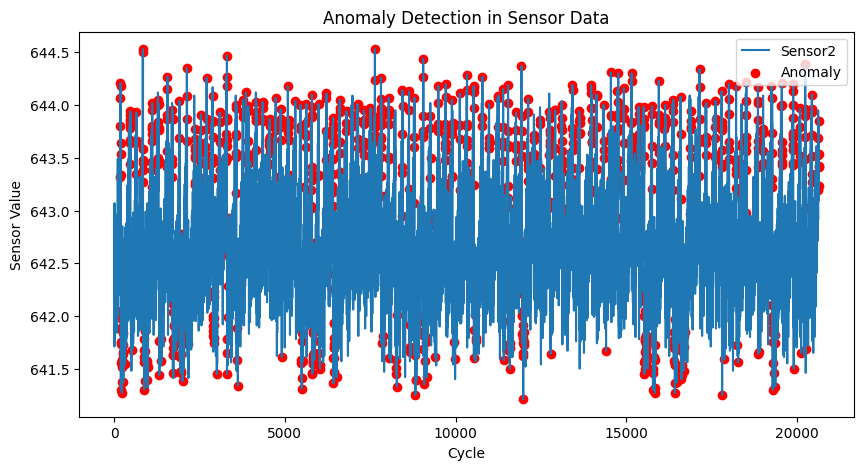

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(data['sensor2'], label='Sensor2')

plt.scatter(anomalies.index, anomalies['sensor2'],
            color='red', label='Anomaly')

plt.legend()
plt.title("Anomaly Detection in Sensor Data")
plt.xlabel("Cycle")
plt.ylabel("Sensor Value")

plt.show()

In [33]:
def decision_engine(row):

    if row['anomaly'] == -1:
        return "⚠️ Anomaly Detected - Check System"

    elif row['sensor2'] > 0.8:
        return "🔥 High Temperature - Reduce Load"

    elif row['sensor3'] < 0.2:
        return "⚡ Low Performance - Inspect System"

    else:
        return "✅ Normal Operation"

In [34]:
data['decision'] = data.apply(decision_engine, axis=1)

print(data[['sensor2','sensor3','anomaly','decision']].head())

   sensor2  sensor3  anomaly                          decision
0   641.82  1589.70        1  🔥 High Temperature - Reduce Load
1   642.15  1591.82        1  🔥 High Temperature - Reduce Load
2   642.35  1587.99        1  🔥 High Temperature - Reduce Load
3   642.35  1582.79        1  🔥 High Temperature - Reduce Load
4   642.37  1582.85        1  🔥 High Temperature - Reduce Load


In [35]:
print(data['decision'].value_counts())

decision
🔥 High Temperature - Reduce Load      19599
⚠️ Anomaly Detected - Check System     1032
Name: count, dtype: int64


In [36]:
alerts = data[data['anomaly'] == -1]

print(alerts[['sensor2','sensor3','decision']].head())

     sensor2  sensor3                            decision
181   644.21  1602.08  ⚠️ Anomaly Detected - Check System
183   644.07  1605.44  ⚠️ Anomaly Detected - Check System
184   643.80  1603.46  ⚠️ Anomaly Detected - Check System
186   643.32  1592.10  ⚠️ Anomaly Detected - Check System
188   644.18  1596.17  ⚠️ Anomaly Detected - Check System


In [37]:
def risk_score(row):
    if row['anomaly'] == -1:
        return "High Risk"
    elif row['sensor2'] > 0.7:
        return "Medium Risk"
    else:
        return "Low Risk"

data['risk'] = data.apply(risk_score, axis=1)

In [38]:
features = ['sensor2','sensor3','sensor4','sensor7','sensor11']

In [39]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data[features] = scaler.fit_transform(data[features])

In [40]:
# Get max cycle per engine
max_cycle = data.groupby('engine_id')['cycle'].max().reset_index()
max_cycle.columns = ['engine_id','max_cycle']

# Merge
data = data.merge(max_cycle, on='engine_id')

# Create RUL
data['RUL'] = data['max_cycle'] - data['cycle']

print(data[['engine_id','cycle','RUL']].head())

   engine_id  cycle  RUL
0          1      1  191
1          1      2  190
2          1      3  189
3          1      4  188
4          1      5  187


In [41]:
import numpy as np

sequence_length = 20

X = []
y = []

for i in range(len(data) - sequence_length):
    X.append(data[features].iloc[i:i+sequence_length].values)
    y.append(data['RUL'].iloc[i+sequence_length])

X = np.array(X)
y = np.array(y)

print(X.shape, y.shape)

KeyboardInterrupt: 

In [ ]:
import numpy as np

sequence_length = 10

X = []
y = []

for i in range(len(data) - sequence_length):
    X.append(data[features].iloc[i:i+sequence_length].values)
    y.append(data['RUL'].iloc[i+sequence_length])

X = np.array(X)
y = np.array(y)

print(X.shape, y.shape)

In [ ]:
data = data[data['engine_id'] <= 2]   # only 2 engines
data = data.head(1500)                # limit rows

NameError: name 'data' is not defined

In [42]:
data = data[data['engine_id'] <= 2]   # only 2 engines
data = data.head(1500)                # limit rows

In [43]:
features = ['sensor2','sensor3','sensor4']

In [44]:
sequence_length = 5

In [45]:
import numpy as np

X = []
y = []

for i in range(0, len(data) - sequence_length, 2):
    # step=2 reduces number of sequences

    X.append(data[features].iloc[i:i+sequence_length].values)
    y.append(data['RUL'].iloc[i+sequence_length])

X = np.array(X)
y = np.array(y)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (237, 5, 3)
Shape of y: (237,)


In [46]:
from keras.models import Sequential
from keras.layers import LSTM, Dense

model = Sequential()

model.add(LSTM(32, input_shape=(X.shape[1], X.shape[2])))  # reduced units
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [47]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Input

model = Sequential()

model.add(Input(shape=(X.shape[1], X.shape[2])))
model.add(LSTM(32))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

In [48]:
from keras.models import Sequential
from keras.layers import Dense

model = Sequential()

model.add(Dense(16, activation='relu', input_dim=3))
model.add(Dense(8, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(3))

model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [49]:
features = ['sensor2','sensor3','sensor4']
X = data[features]

In [50]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [51]:
model.fit(X_scaled, X_scaled, epochs=10, batch_size=32, verbose=1)

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1712
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0980 
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0466 
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0199 
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0119 
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0099 
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0080 
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0066 
Epoch 9/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0055 
Epoch 10/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0046 


In [52]:
reconstructed = model.predict(X_scaled)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [53]:
import numpy as np

mse = np.mean(np.power(X_scaled - reconstructed, 2), axis=1)

In [54]:
threshold = np.percentile(mse, 95)

In [55]:
data['ae_anomaly'] = mse > threshold

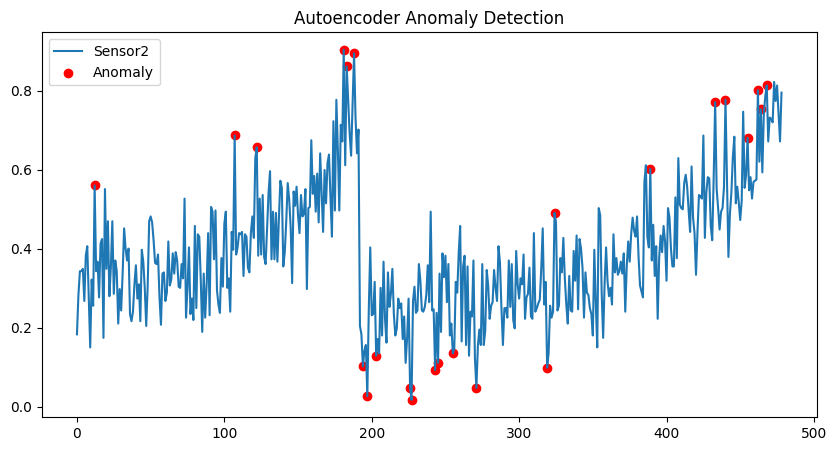

In [56]:
import matplotlib.pyplot as plt

anomalies = data[data['ae_anomaly'] == True]

plt.figure(figsize=(10,5))

plt.plot(data['sensor2'], label='Sensor2')
plt.scatter(anomalies.index, anomalies['sensor2'],
            color='red', label='Anomaly')

plt.legend()
plt.title("Autoencoder Anomaly Detection")
plt.show()

In [59]:
!pip install streamlit
!pip install pyngrok

In [ ]:
app.py

NameError: name 'app' is not defined

In [61]:
with open("app.py", "w") as f:
    f.write("")

In [60]:
%%writefile app.py

Overwriting app.py


In [ ]:
%%writefile app.py
import streamlit as st

st.title("🚀 My Dashboard")
st.write("Hello World")

Overwriting app.py


In [ ]:
!pip install streamlit pyngrok

In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹

⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.240.236.193:8501

  Stopping...
^C


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹

⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴your url is: https://sour-hats-judge.loca.lt

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.240.236.193:8501

  Stopping...
^C


In [ ]:
!curl ipv4.icanhazip.com

35.240.236.193


In [ ]:
%%writefile app.py

Overwriting app.py


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.title("🚀 AI-Based Spacecraft Monitoring System")

uploaded_file = st.file_uploader("Upload your dataset")

if uploaded_file:
    data = pd.read_csv(uploaded_file)

    st.subheader("Dataset Preview")
    st.write(data.head())

    sensor = st.selectbox("Select Sensor", data.columns[2:10])

    fig, ax = plt.subplots()
    ax.plot(data[sensor], label="Sensor Data")

    if 'anomaly' in data.columns:
        anomalies = data[data['anomaly'] == -1]
        ax.scatter(anomalies.index, anomalies[sensor],
                   color='red', label='Anomaly')

    ax.legend()
    st.pyplot(fig)

    if 'decision' in data.columns:
        st.write(data['decision'].value_counts())

    if 'RUL' in data.columns:
        st.line_chart(data['RUL'])

Overwriting app.py


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹

⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴your url is: https://fruity-glasses-leave.loca.lt

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.240.236.193:8501



ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



  Stopping...
  Stopping...



KeyboardInterrupt



In [ ]:
data.to_csv("final_output.csv", index=False)

In [ ]:
import os
print(os.getcwd())
print(os.listdir())

/content
['.config', 'final_output.csv', 'train_FD001.txt', 'app.py', 'sample_data']


In [ ]:
 !pip install streamlit pyngrok

In [ ]:
!streamlit run app.py & npx localtunnel --port 8501



⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.240.236.193:8501

your url is: https://mean-cups-end.loca.lt
  Stopping...
^C


In [1]:
%%writefile app.py

Writing app.py


In [ ]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

# Title
st.title("🚀 AI-Based Spacecraft Monitoring System")

# Upload file
uploaded_file = st.file_uploader("Upload your dataset (CSV)")

if uploaded_file is not None:
    # Read data
    data = pd.read_csv(uploaded_file)

    # Show data
    st.subheader("📊 Dataset Preview")
    st.write(data.head())

    # Select sensor column
    st.subheader("📈 Sensor Visualization")
    sensor = st.selectbox("Select Sensor", data.columns)

    # Plot sensor graph
    fig, ax = plt.subplots()
    ax.plot(data[sensor], label="Sensor Data")

    # Show anomalies if present
    if 'anomaly' in data.columns:
        anomalies = data[data['anomaly'] == -1]
        ax.scatter(anomalies.index, anomalies[sensor],
                   color='red', label='Anomaly')

        st.success(f"Total Anomalies Detected: {len(anomalies)}")

    ax.legend()
    st.pyplot(fig)

    # Show decision output
    if 'decision' in data.columns:
        st.subheader("⚙️ Decision System Output")
        st.write(data['decision'].value_counts())

    # Show RUL
    if 'RUL' in data.columns:
        st.subheader("⏳ Remaining Useful Life (RUL)")
        st.line_chart(data['RUL'])

else:
    st.info("Please upload a CSV file to proceed.")

2026-03-24 05:31:08.533 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 05:31:08.678 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-03-24 05:31:08.679 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 05:31:08.681 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 05:31:08.683 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 05:31:08.685 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 05:31:08.687 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-24 05:31:08.689 Thread 'MainThread': mi

In [ ]:
from pyngrok import ngrok

!streamlit run app.py &

public_url = ngrok.connect(8501)
print(public_url)




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.240.236.193:8501

  Stopping...


ERROR:pyngrok.process.ngrok:t=2026-03-24T05:36:50+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-03-24T05:36:50+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-03-24T05:36:50+0000 lvl=eror msg="terminating with error" obj=app err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your aut

PyngrokNgrokError: The ngrok process errored on start: authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.

In [5]:
import sys
!{sys.executable} -m pip install streamlit pyngrok
from pyngrok import ngrok

# Reset
ngrok.kill()

# Start streamlit
!python -m streamlit run app.py &

# Get public link
public_url = ngrok.connect(8501, "http")

print("👉 OPEN THIS LINK:", public_url)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 109.0 MB/s eta 0:00:00



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.234.32.245:8501

  Stopping...


ERROR:pyngrok.process.ngrok:t=2026-03-26T02:08:55+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-03-26T02:08:55+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-03-26T02:08:55+0000 lvl=eror msg="terminating with error" obj=app err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your aut

PyngrokNgrokError: The ngrok process errored on start: authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.

In [6]:
from pyngrok import ngrok

# kill previous sessions
ngrok.kill()

# connect to port 8501
public_url = ngrok.connect(8501)

print("👉 OPEN THIS LINK:", public_url)

ERROR:pyngrok.process.ngrok:t=2026-03-26T02:09:04+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-03-26T02:09:04+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-03-26T02:09:04+0000 lvl=eror msg="terminating with error" obj=app err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your aut

PyngrokNgrokError: The ngrok process errored on start: authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.

In [7]:
!ngrok config add-authtoken 3BSmsXrmjFoYoUf41hGtunU7ZUZ_uh5jZ48rub7Z7wryQiDf

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [8]:
from pyngrok import ngrok

# kill previous sessions
ngrok.kill()

# connect to port 8501
public_url = ngrok.connect(8501)

print("👉 OPEN THIS LINK:", public_url)

👉 OPEN THIS LINK: NgrokTunnel: "https://uncompromising-unswingled-maisie.ngrok-free.dev" -> "http://localhost:8501"


In [9]:
from pyngrok import ngrok

# Stop any previous tunnels
ngrok.kill()

# Run your app
!streamlit run app.py &

# Create public link
public_url = ngrok.connect(8501)

print("👉 OPEN THIS LINK:", public_url)




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.234.32.245:8501

  Stopping...
👉 OPEN THIS LINK: NgrokTunnel: "https://uncompromising-unswingled-maisie.ngrok-free.dev" -> "http://localhost:8501"


In [10]:
from pyngrok import ngrok

# stop old tunnels
ngrok.kill()

# create new public link
public_url = ngrok.connect(8501)

print("👉 OPEN THIS LINK:", public_url)

👉 OPEN THIS LINK: NgrokTunnel: "https://uncompromising-unswingled-maisie.ngrok-free.dev" -> "http://localhost:8501"


In [11]:
!streamlit run app.py &>/dev/null &

In [12]:
from pyngrok import ngrok

ngrok.kill()

public_url = ngrok.connect(8501)

print("👉 OPEN THIS LINK:", public_url)

👉 OPEN THIS LINK: NgrokTunnel: "https://uncompromising-unswingled-maisie.ngrok-free.dev" -> "http://localhost:8501"


In [13]:
%%writefile app.py

Overwriting app.py


In [14]:
!pip install streamlit pyngrok

In [15]:
!streamlit run app.py &>/dev/null &

In [18]:
from pyngrok import ngrok

ngrok.kill()
public_url = ngrok.connect(8501)

print("👉 OPEN THIS LINK:", public_url)

👉 OPEN THIS LINK: NgrokTunnel: "https://uncompromising-unswingled-maisie.ngrok-free.dev" -> "http://localhost:8501"


In [17]:
%%writefile app.py
import streamlit as st
import pandas as pd

st.title("🚀 Spacecraft Monitoring")

file = st.file_uploader("Upload CSV")

if file:
    data = pd.read_csv(file)
    st.write(data.head())
    st.line_chart(data.select_dtypes(include=['number']))

Overwriting app.py


In [19]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

st.title("🚀 AI-Based Spacecraft Monitoring System")

# Upload CSV
file = st.file_uploader("Upload CSV File")

if file:
    data = pd.read_csv(file)

    # Show data
    st.subheader("📊 Dataset Preview")
    st.write(data.head())

    # Select only sensor columns
    sensor_cols = [col for col in data.columns if "sensor" in col]

    st.subheader("📈 Sensor Visualization")

    selected_sensor = st.selectbox("Select a Sensor", sensor_cols)

    fig, ax = plt.subplots()
    ax.plot(data[selected_sensor], label=selected_sensor)

    # Show anomalies
    if 'anomaly' in data.columns:
        anomalies = data[data['anomaly'] == -1]
        ax.scatter(anomalies.index, anomalies[selected_sensor],
                   color='red', label='Anomaly')

        st.success(f"Anomalies detected: {len(anomalies)}")

    ax.legend()
    st.pyplot(fig)

    # RUL
    if 'RUL' in data.columns:
        st.subheader("⏳ Remaining Useful Life")
        st.line_chart(data['RUL'])

else:
    st.info("Upload your dataset to begin")

Overwriting app.py


In [57]:
# True condition (failure if RUL < 50)
data['true_label'] = (data['RUL'] < 50).astype(int)

In [64]:
# from autoencoder
data['anomaly'] = (mse > threshold).astype(int)

In [66]:
X_pred = model.predict(X_scaled)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [68]:
import numpy as np

mse = np.mean(np.power(X_scaled - X_pred, 2), axis=1)

In [69]:
threshold = np.percentile(mse, 95)

In [70]:
data = data.iloc[:len(mse)]  # align lengths

data['anomaly'] = (mse > threshold).astype(int)

In [71]:
y_true = data['true_label']
y_pred = data['anomaly']

In [72]:
print(data[['RUL', 'true_label', 'anomaly']].head())

   RUL  true_label  anomaly
0  191           0        0
1  190           0        0
2  189           0        0
3  188           0        0
4  187           0        0


In [73]:
 from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_true = data['true_label']
y_pred = data['anomaly']

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.778705636743215
Precision: 0.375
Recall: 0.09
F1 Score: 0.14516129032258066


In [74]:
data_metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

In [75]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

st.set_page_config(page_title="🚀 Spacecraft Monitoring", layout="wide")

st.title("🚀 AI-Based Spacecraft Monitoring System")

# Upload CSV
uploaded_file = st.file_uploader("Upload your CSV file", type=["csv"])

if uploaded_file is not None:
    data = pd.read_csv(uploaded_file)

    st.subheader("📊 Dataset Preview")
    st.dataframe(data.head())

    # Metrics
    if 'true_label' in data.columns and 'anomaly' in data.columns:
        y_true = data['true_label']
        y_pred = data['anomaly']

        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred)
        recall = recall_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)

        st.subheader("📈 Model Performance")

        col1, col2, col3, col4 = st.columns(4)

        col1.metric("Accuracy", f"{accuracy:.2f}")
        col2.metric("Precision", f"{precision:.2f}")
        col3.metric("Recall", f"{recall:.2f}")
        col4.metric("F1 Score", f"{f1:.2f}")

        # Confusion Matrix
        st.subheader("📉 Confusion Matrix")
        cm = confusion_matrix(y_true, y_pred)

        fig, ax = plt.subplots()
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(ax=ax)
        st.pyplot(fig)

    # Sensor Visualization
    st.subheader("📡 Sensor Data Visualization")
    sensor = st.selectbox("Select Sensor", data.columns)

    st.line_chart(data[sensor])


2026-03-26 03:07:09.128 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 03:07:09.130 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 03:07:10.436 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-03-26 03:07:10.440 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 03:07:10.444 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 03:07:10.448 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 03:07:10.450 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [76]:
st.sidebar.title("Navigation")
option = st.sidebar.radio("Go to", ["Home", "Data", "Model Results"])

2026-03-26 03:07:32.391 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 03:07:32.394 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 03:07:32.396 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 03:07:32.398 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 03:07:32.401 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 03:07:32.405 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 03:07:32.407 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 03:07:32.410 Session state does not function when running a script without `streamlit run`
2026-03-26 03:07

In [77]:
st.markdown("""
    <style>
    .main {
        background-color: #0E1117;
    }
    </style>
""", unsafe_allow_html=True)

2026-03-26 03:07:45.102 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 03:07:45.105 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 03:07:45.114 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [78]:
if 'anomaly' in data.columns:
    if data['anomaly'].iloc[-1] == 1:
        st.error("⚠️ Anomaly Detected!")
    else:
        st.success("✅ System Normal")

2026-03-26 03:08:00.775 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 03:08:00.779 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 03:08:00.782 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [79]:
!pip install streamlit pyngrok

In [80]:
from pyngrok import ngrok
ngrok.set_auth_token("3BSmsXrmjFoYoUf41hGtunU7ZUZ_uh5jZ48rub7Z7wryQiDf")

In [81]:
!streamlit run app.py &




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.234.32.245:8501

  Stopping...


In [82]:
!streamlit run app.py &
public_url = ngrok.connect(8501)
print(public_url)




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.234.32.245:8501

  Stopping...
NgrokTunnel: "https://uncompromising-unswingled-maisie.ngrok-free.dev" -> "http://localhost:8501"


In [83]:
!ps aux | grep streamlit

root       28125  0.0  0.0   7372  3492 ?        S    03:16   0:00 /bin/bash -c ps aux | grep streamlit
root       28127  0.0  0.0   6480  2380 ?        S    03:16   0:00 grep streamlit


In [84]:
!streamlit run app.py &
public_url = ngrok.connect(8501)
print(public_url)




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.234.32.245:8501

  Stopping...
NgrokTunnel: "https://uncompromising-unswingled-maisie.ngrok-free.dev" -> "http://localhost:8501"


In [85]:
import streamlit as st

st.title("🚀 Test App Running")
st.write("If you see this, Streamlit is working!")

2026-03-26 03:19:45.697 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 03:19:45.705 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 03:19:45.710 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 03:19:45.718 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 03:19:45.725 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 03:19:45.727 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [86]:
!pip install streamlit pyngrok

In [87]:
%%writefile app.py
import streamlit as st

st.title("🚀 Streamlit Working!")
st.write("Now everything is correct ✅")

Overwriting app.py


In [88]:
!streamlit run app.py &




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.234.32.245:8501

  Stopping...


In [89]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

# Page settings
st.set_page_config(page_title="🚀 Spacecraft Monitoring", layout="wide")

# Title
st.title("🚀 AI-Based Spacecraft Monitoring System")

# Sidebar
st.sidebar.title("Navigation")
option = st.sidebar.radio("Go to", ["Home", "Data", "Model Results"])

# Upload file
uploaded_file = st.file_uploader("📂 Upload your CSV file", type=["csv"])

if uploaded_file is None:
    st.warning("⚠️ Please upload your dataset to continue")
else:
    data = pd.read_csv(uploaded_file)

    # HOME
    if option == "Home":
        st.subheader("📊 Overview")
        st.write("This system detects anomalies and predicts failures in spacecraft systems.")

    # DATA
    elif option == "Data":
        st.subheader("📄 Dataset Preview")
        st.dataframe(data.head())

        st.subheader("📡 Sensor Visualization")
        sensor = st.selectbox("Select Column", data.columns)
        st.line_chart(data[sensor])

    # MODEL RESULTS
    elif option == "Model Results":

        if 'true_label' in data.columns and 'anomaly' in data.columns:

            y_true = data['true_label']
            y_pred = data['anomaly']

            # Metrics
            accuracy = accuracy_score(y_true, y_pred)
            precision = precision_score(y_true, y_pred)
            recall = recall_score(y_true, y_pred)
            f1 = f1_score(y_true, y_pred)

            st.subheader("📈 Model Performance")

            col1, col2, col3, col4 = st.columns(4)
            col1.metric("Accuracy", f"{accuracy:.2f}")
            col2.metric("Precision", f"{precision:.2f}")
            col3.metric("Recall", f"{recall:.2f}")
            col4.metric("F1 Score", f"{f1:.2f}")

            # Status
            if data['anomaly'].iloc[-1] == 1:
                st.error("⚠️ Anomaly Detected!")
            else:
                st.success("✅ System Normal")

            # Confusion Matrix
            st.subheader("📉 Confusion Matrix")
            cm = confusion_matrix(y_true, y_pred)

            fig, ax = plt.subplots()
            disp = ConfusionMatrixDisplay(confusion_matrix=cm)
            disp.plot(ax=ax)
            st.pyplot(fig)

        else:
            st.error("❌ Required columns not found (true_label, anomaly)")

2026-03-26 03:26:19.217 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 03:26:19.221 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 03:26:19.228 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 03:26:19.237 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 03:26:19.240 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 03:26:19.248 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 03:26:19.250 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 03:26:19.256 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [92]:
!streamlit run app.py &




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.234.32.245:8501

  Stopping...


In [91]:
from pyngrok import ngrok
public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://uncompromising-unswingled-maisie.ngrok-free.dev" -> "http://localhost:8501"


In [93]:
!streamlit run app.py &
from pyngrok import ngrok
public_url = ngrok.connect(8501)
print(public_url)




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.234.32.245:8501

  Stopping...
NgrokTunnel: "https://uncompromising-unswingled-maisie.ngrok-free.dev" -> "http://localhost:8501"


In [94]:
!pip install streamlit pyngrok

In [95]:
%%writefile app.py
import streamlit as st
import pandas as pd

st.title("🚀 AI-Based Spacecraft Monitoring System")

data = pd.read_csv("final_output.csv")

st.subheader("Dataset")
st.write(data.head())

if 'RUL' in data.columns:
    st.subheader("RUL Graph")
    st.line_chart(data['RUL'])

if 'anomaly' in data.columns:
    st.subheader("Anomalies")
    st.write(data[data['anomaly'] == 1])

Overwriting app.py


In [96]:
!streamlit run app.py &>/dev/null &

In [97]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print("👉 OPEN THIS LINK:", public_url)

👉 OPEN THIS LINK: NgrokTunnel: "https://uncompromising-unswingled-maisie.ngrok-free.dev" -> "http://localhost:8501"


In [98]:
%%writefile app.py
import streamlit as st
import pandas as pd

st.title("🚀 AI-Based Spacecraft Monitoring System")

# Upload file
uploaded_file = st.file_uploader("Upload your CSV file", type=["csv"])

if uploaded_file is None:
    st.warning("⚠️ Please upload your dataset")
else:
    data = pd.read_csv(uploaded_file)

    st.subheader("📊 Dataset Preview")
    st.write(data.head())

    if 'RUL' in data.columns:
        st.subheader("📈 RUL Graph")
        st.line_chart(data['RUL'])

    if 'anomaly' in data.columns:
        st.subheader("🚨 Detected Anomalies")
        st.write(data[data['anomaly'] == 1])

Overwriting app.py


In [99]:
import pandas as pd

data = pd.read_csv("final_output.csv")
print(data.columns)

FileNotFoundError: [Errno 2] No such file or directory: 'final_output.csv'

In [100]:
os.listdir()

NameError: name 'os' is not defined

In [102]:
import os
os.listdir()

['.config', 'app.py', 'train_FD001.txt', 'sample_data']

In [103]:
data.to_csv("final_output.csv", index=False)

In [104]:
 # create true labels
data['true_label'] = (data['RUL'] < 50).astype(int)

# predicted anomaly (already from model)
data['anomaly'] = (mse > threshold).astype(int)

# save final file
data.to_csv("final_output.csv", index=False)

In [105]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

st.set_page_config(page_title="🚀 Spacecraft Monitoring", layout="wide")

st.title("🚀 AI-Based Spacecraft Monitoring System")

uploaded_file = st.file_uploader("📂 Upload your CSV file", type=["csv"])

if uploaded_file is None:
    st.warning("⚠️ Please upload your dataset")
else:
    data = pd.read_csv(uploaded_file)

    st.subheader("📊 Dataset Preview")
    st.dataframe(data.head())

    # CHECK REQUIRED COLUMNS
    if 'true_label' in data.columns and 'anomaly' in data.columns:

        y_true = data['true_label']
        y_pred = data['anomaly']

        # ✅ METRICS
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred)
        recall = recall_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)

        st.subheader("📈 Model Performance")

        col1, col2, col3, col4 = st.columns(4)
        col1.metric("Accuracy", f"{accuracy:.2f}")
        col2.metric("Precision", f"{precision:.2f}")
        col3.metric("Recall", f"{recall:.2f}")
        col4.metric("F1 Score", f"{f1:.2f}")

        # ✅ STATUS
        if data['anomaly'].iloc[-1] == 1:
            st.error("⚠️ Anomaly Detected!")
        else:
            st.success("✅ System Normal")

        # ✅ CONFUSION MATRIX
        st.subheader("📉 Confusion Matrix")

        cm = confusion_matrix(y_true, y_pred)

        fig, ax = plt.subplots()
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(ax=ax)

        st.pyplot(fig)

    else:
        st.error("❌ Missing columns: true_label or anomaly")

    # 📡 GRAPH
    st.subheader("📡 Sensor Visualization")
    column = st.selectbox("Select Column", data.columns)
    st.line_chart(data[column])

Overwriting app.py


In [106]:
!streamlit run app.py &




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8502
  Network URL: http://172.28.0.12:8502
  External URL: http://35.234.32.245:8502

  Stopping...


In [107]:
from pyngrok import ngrok
print(ngrok.connect(8501))

NgrokTunnel: "https://uncompromising-unswingled-maisie.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
!streamlit run app.py &
from pyngrok import ngrok
print(ngrok.connect(8501))




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.234.32.245:8501

